### 1. Dependencies

In [ ]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe,get_japan_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_famafrench_factors, get_processed_index, get_accounting_data
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe, process_japan_universe

In [ ]:
# MANUAL INPUT


start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#sector split
top_x_by_industry_even_split = 6



# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

Filters

In [ ]:
#Important Filters
##############################
region_analysis = "Europe_and_North_America_and_Japan"

esg_choice = "none" # "refinitiv_n_s&p"#"s&p"#"s&p"#"none"#""refinitiv_n_s&p" #refinitiv"

#Univariate Sorting Percentile Split number
no_simple_quantiles = 6

add_accounting_data = True

show_sector_portfolio = False
##############################


#Other Initalising variables
drop_real_estate = True
fama_factor_region = "Developed"
currency_filter=None
convert_to_USD = True


if region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    

if region_analysis == "Europe_and_North_America_and_Japan":
    #currencies we keep
    currency_filter = ['EUR', 'USD', 'JPY'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    


elif region_analysis == "North_America":
    currency_filter = ['USD'] 
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    fama_factor_region = "North_America"
    convert_to_USD = False
    

elif region_analysis == "Europe":
    currency_filter = ['EUR'] #"None" for uk
    region_filter = ["Europe"]
    execute_region_filters = True 
    #Keep in local currency
    #If we dont filter by EUR
    convert_to_USD = False    #True if UK
    fama_factor_region = "Europe"
  

elif region_analysis == "Japan":
    currency_filter = ['JPY'] 
    region_filter = ["Asia-Pacific"]
    execute_region_filters = True 
    #Keep in local currency
    convert_to_USD = False
    fama_factor_region = "Japan"

Signal Design

In [ ]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo, test_multiple_signals

#Choose which action characterization to use, which is dependent on function

#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()
#categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = test_multiple_signals()


#What signals to include~~~
lc_signals = {
    "signal_0": signal_0_name,
    "signal_1": signal_1_name,
    "signal_2": signal_2_name,
   
}

Signal Choice

In [ ]:

analyse_high_low = "high"
if esg_choice == "none":

    universe_signals = {}

    if analyse_high_low == "High":
        analysis_selection = [("signal_2", "high"), ("signal_1","high"), ("signal_0","high")]
    elif analyse_high_low == "Low":
        analysis_selection = [("signal_2", "low"), ("signal_1","low"), ("signal_0","low")]



elif esg_choice == "refinitiv":
    universe_signals = {"esg_refinitive": "esg_refinitive",}
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high")]
elif esg_choice == "s&p":
    universe_signals = {    "esg_sp": "esg_sp",}
    analysis_selection = [("signal_2", "high"), ("esg_sp", "high")]
elif esg_choice == "refinitiv_n_s&p":
    universe_signals = {    "esg_sp": "esg_sp",    "esg_refinitive": "esg_refinitive",}
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high"), ("esg_sp", "high")]

### 2. Data

Golden Data

In [ ]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"

# Golden Dataset
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')
lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')


#### 2.1 LC dataset

clean below

In [ ]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)


if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']

#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]


Getting SDG-Secific Signals

In [ ]:

#signal_type = "all_SDG_1D" # all_sdgs" # "people" # "people" #"planet"#"people"#"all_actions" # #
# from functions.signal_design.people_vs_planet import people_vs_planet
# categories_dict_people, categories_dict_planet, categories_dict_people_advocacy, categories_dict_planet_advocacy, categories_dict_prosperity, categories_dict_prosperity_advocacy, categories_dict_all_sdgs, categories_dict_all_sdgs_advocacy = people_vs_planet(categories_dict_actions)


# if signal_type == "all_SDG_1D":
#     categories_dict = dict_all_SDG_1D
# elif signal_type == "people":
#     categories_dict = categories_dict_people
# elif signal_type == "planet":
#     categories_dict = categories_dict_planet
# elif signal_type == "prosperity":
#     categories_dict = categories_dict_prosperity
# elif signal_type == "all_sdgs":
#     categories_dict = categories_dict_all_sdgs


1) Can use the total activites from all SDGS
2) Sub sample

In [ ]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [ ]:
lc["sum_activities"].describe()

count    62835.000000
mean        26.837161
std         32.263574
min          0.000000
25%          7.000000
50%         17.000000
75%         34.000000
max        699.000000
Name: sum_activities, dtype: float64

In [ ]:
lc = filter_sum_activities_by_fiscal_year_quantiles(
    lc,
    lower_exclude= (alpha_bound/2),
    upper_exclude= (alpha_bound/2),
)

In [ ]:
lc["sum_activities"].describe()

count    55539.000000
mean        22.976737
std         19.134424
min          3.000000
25%          8.000000
50%         17.000000
75%         32.000000
max        137.000000
Name: sum_activities, dtype: float64

Create the signal

In [ ]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [ ]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

5991

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4 - Japan

5 - ESG

4- Fama-French

5- Global Universe

6- Accounting Data

In [ ]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)

# Keep local-currency series for Europe/Japan analysis (no FX conversion)

usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year, end_year, download_wrds_data=False)
row_universe = process_row_universe(row_universe,fx_rates,convert_to_USD,)

japan_universe = get_japan_universe(start_year, end_year, download_wrds_data=False)
japan_universe = process_japan_universe(japan_universe,fx_rates,convert_to_USD,)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100
    japan_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == 'refinitiv_n_s&p':
        usa_universe, row_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe)
        usa_universe, row_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe)
    elif esg_choice == "refinitiv":
        usa_universe, row_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe)

fama_french = get_famafrench_factors(
    start_year,
    end_year,
    fama_factor_region,
    download_developed_ff_data=False,
)

global_universe = process_global_universe(usa_universe,row_universe,japan_universe,currency_filter,mktcap_covered,
    esg_choice,)

print("columns with year")
print([c for c in global_universe.columns if c == 'year' or c.startswith('year_')])

if add_accounting_data:
    #Note this will result in a lower sample and non-profitable stocks will be removed
    global_universe = global_universe.drop(columns=['year_x'], errors='ignore')
    global_universe = get_accounting_data(global_universe, region_analysis, start_year, end_year, dowload_acc_data = True)


#Ensure gvkey is 6 digits for merging
global_universe["gvkey"] = global_universe["gvkey"].astype(str).str.zfill(6)
lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)

In [ ]:
global_universe["gvkey"].astype(str).str.len().value_counts()   

gvkey
6    5883855
Name: count, dtype: int64

In [ ]:
lc["gvkey"].astype(str).str.len().value_counts()   

gvkey
6    55539
Name: count, dtype: int64

### 3. Univariate Portfolio sorting

In [ ]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']



prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    lc_signals=lc_signals,
    universe_signals=universe_signals,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french




In [ ]:
if add_accounting_data:
    #Amount of missing accounting data as a percent
    cols = ["roa0","roa1","roa2","ros0","ros1","ros2","sales_intensity"]
    print((100 * global_universe[cols].isna().mean()).sort_values(ascending=False))

ros0               5.827726
ros2               5.723106
ros1               5.198714
sales_intensity    5.167715
roa2               0.795629
roa0               0.679385
roa1               0.213115
dtype: float64


In [ ]:
global_universe.to_csv(f"./data/Global_Universe/Global_Universe_{region_analysis}_{end_year}")

In [ ]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [ ]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

Store constituents over time + compute “next-month return” by Industry

In [ ]:
from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio


if show_sector_portfolio:
    # Sector portfolio is pinned to signal_2.
    global_signal_2 = signals["signal_2"]

    #Build an industry pivot aligned to global_returns  and global_signal_*
    global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

    #This will automatically split the even_split_no stocks into the unique sectors.
    #Select the n highest ranked stocks in each industruy and build portfolios using them.
    S = SectorPortfolio(
        signal=global_signal_2,
        returns=global_returns,
        global_universe=global_universe,
        sector_split=top_x_by_industry_even_split,          # fixed N per industry
        manual_input_split=False,
        first_conditioning_set=first_conditioning_set,
        ascending=False,
    )


    #all_industry_returns = S.compute_industry_returns()
    industry_constituents = S.get_constituents_over_time()   

    #Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
    sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


#### Return Preprocessing and adding MSCI

Add MSCI

In [ ]:
file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

Transform in excess returns using the risk free rate

In [ ]:
for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)
if show_sector_portfolio:
    sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)


global_excess_returns_sample = (
    global_returns.mean(axis=1)
    .sub(fama_french["rf"].values, axis=0)
    .to_frame("Global excess returns sample")
)


In [ ]:
global_universe["curcdd"].unique()

array(['USD', 'EUR'], dtype=object)

Make sure the first row is 0, so they all start at the same date

In [ ]:
global_returns = set_first_row_to_zero(global_returns)
for col in signal_quantiles:
    signal_quantiles[col] = set_first_row_to_zero(signal_quantiles[col])
    
MSCI_excess_returns.iloc[0]      = 0

if show_sector_portfolio:
    sector_portfolio_returns.iloc[0] = 0

# 5. Fama-French

In [ ]:

if show_sector_portfolio:
    sector_portfolio_returns_df = pd.DataFrame()
    sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
    sector_portfolio_returns = sector_portfolio_returns_df

In [ ]:
from functions.portfolio_metrics.fama_french import ff3_regressions, rolling_ff3_alphas

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]
if show_sector_portfolio:
    ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))
    
ff3_parts.append(ff3_regressions(global_excess_returns_sample, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low advocacy,High advocacy,Low preparation,High preparation,Low transformation,High transformation,Low esg_sp,High esg_sp,Low esg_refinitive,High esg_refinitive,Sector equal split transformation,Global excess returns sample
alpha,-0.03,-0.00,0.03,0.03,0.05,0.05,0.01,-0.10,0.03,-0.01,0.08,0.07
beta_mkt,1.13,1.10,1.10,1.14,1.08,1.09,1.13,1.08,1.10,1.20,1.00,1.13
beta_smb,0.16,0.17,0.10,0.14,0.12,0.16,0.24,-0.07,0.12,0.10,-0.04,0.16
beta_hml,0.21,0.23,0.18,0.22,0.21,0.21,0.15,0.29,0.13,0.39,0.11,0.27
p-value(alpha),0.81,0.99,0.79,0.81,0.71,0.65,0.92,0.51,0.83,0.94,0.57,0.43


#### Rolling Alpha

In [ ]:
window_size = 40


analyse_high_low = "Low"
analyse_high_low = "High"



if analyse_high_low == "High":
        analysis_selection = [("signal_2", "high"), ("signal_1","high"), ("signal_0","high")]
elif analyse_high_low == "Low":
    analysis_selection = [("signal_2", "low"), ("signal_1","low"), ("signal_0","low")]

rolling_alpha_selection = analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]


if show_sector_portfolio:
    _sector_label = f"Sector equal split {signal_2_name}"
    rolling_signals_arg.append({
        "label": _sector_label,
        "returns": sector_portfolio_returns,
        "alpha_column": _sector_label,
    })

# _market_sample_label = f"Global excess returns sample"
# rolling_signals_arg.append({
#     "label": _market_sample_label,
#     "returns": global_excess_returns_sample,
#     "alpha_column": _market_sample_label,
# })

rolling_alphas = rolling_ff3_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=window_size,
)



# 6. Performance Metrics

In [ ]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns.index)
global_gross_portfolio_returns['Market'] = 1 + global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)

# Single selection shared with rolling alpha.
portfolio_selection = analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles[col][quantile_col]


if show_sector_portfolio:
    _sector_col = f"Sector equal split {signal_2_name}"
    global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

portfolio_returns = global_gross_portfolio_returns - 1

# We only have ESG data till 2023

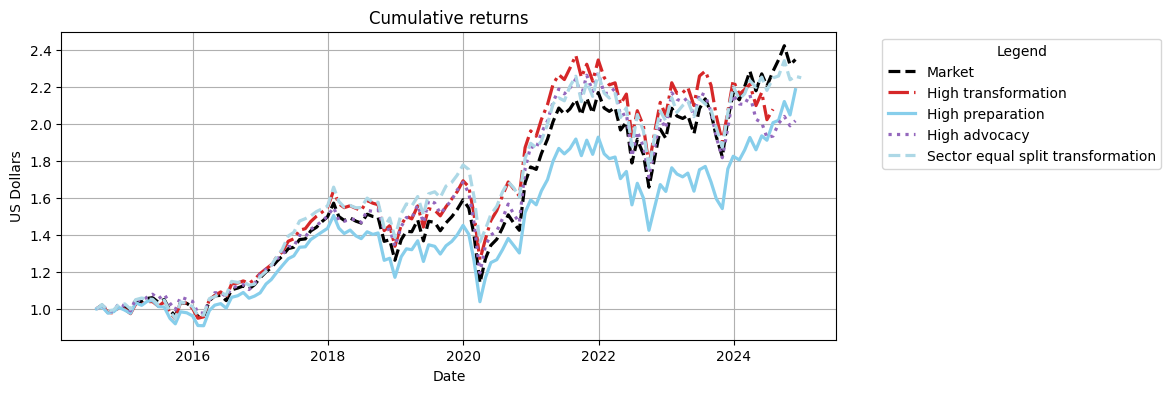

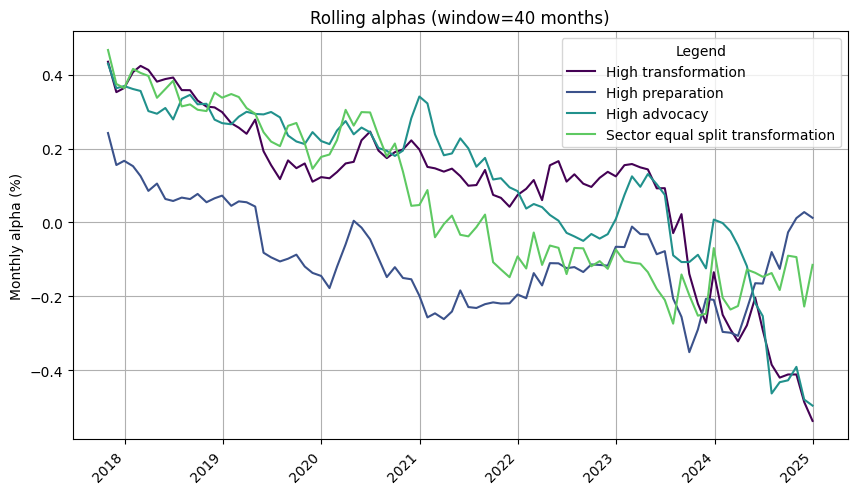

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,,-3.08%,8.18%,8.18%,8.25%,47.74%,133.32%,135.05%
High transformation,,,-7.01%,-7.01%,-11.37%,22.85%,108.46%,108.09%
High preparation,,3.02%,19.74%,19.74%,13.31%,50.59%,120.22%,118.71%
High advocacy,,-1.15%,-6.53%,-6.53%,-11.42%,19.74%,99.19%,101.89%
Sector equal split transformation,-0.37%,-3.97%,2.13%,2.13%,-0.89%,26.53%,119.24%,125.14%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.56,-10.69%,-28.33%,,
High transformation,0.51,-10.72%,-25.28%,0.05,0.650
High preparation,0.52,-10.81%,-31.01%,0.03,0.810
High advocacy,0.48,-10.95%,-29.21%,-0.00,0.990
Sector equal split transformation,0.57,-10.18%,-23.46%,0.08,0.570


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

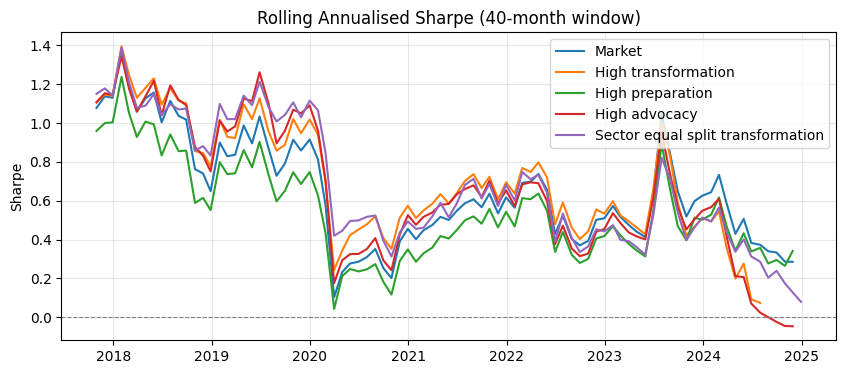

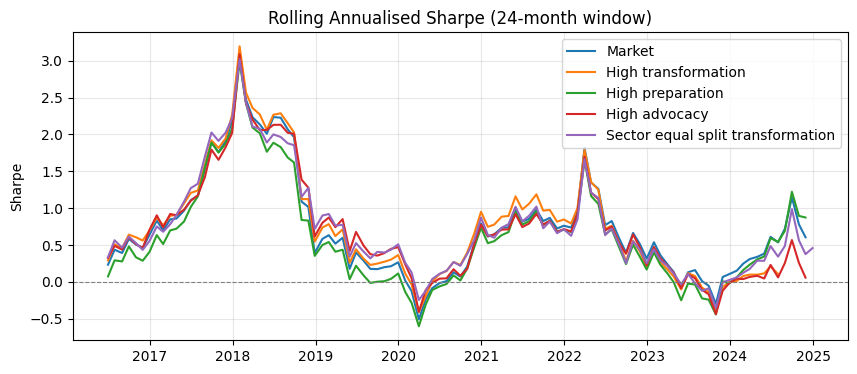

In [ ]:
from functions.portfolio_metrics.Strategy_Perfomance import StrategyPerformance
from functions.portfolio_metrics.fama_french import plot_rolling_alpha_function



start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/{region_analysis}-strategy_cumulative_performance_split{no_simple_quantiles}--ff-{fama_factor_region}_{start_date}-{end_date}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/{region_analysis}-strategy_performance_metrics_split{no_simple_quantiles}--ff-{fama_factor_region}_{start_date}-{end_date}.csv")



sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=f"./output/img/{region_analysis}-cumulative_returns_split{no_simple_quantiles}--ff-{fama_factor_region}.png"
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title="Rolling alphas (window=40 months)",
    save_path=f"./output/img/{region_analysis}-rolling_alphas_split{no_simple_quantiles}-ff-{fama_factor_region}.png",
)

display(cumulative_table)
display(risk_table)


sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/{region_analysis}-strategy_rolling_sharpe_40m_split{no_simple_quantiles}-ff-{fama_factor_region}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/{region_analysis}-strategy_rolling_sharpe_24m_split{no_simple_quantiles}-ff-{fama_factor_region}.png")


# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

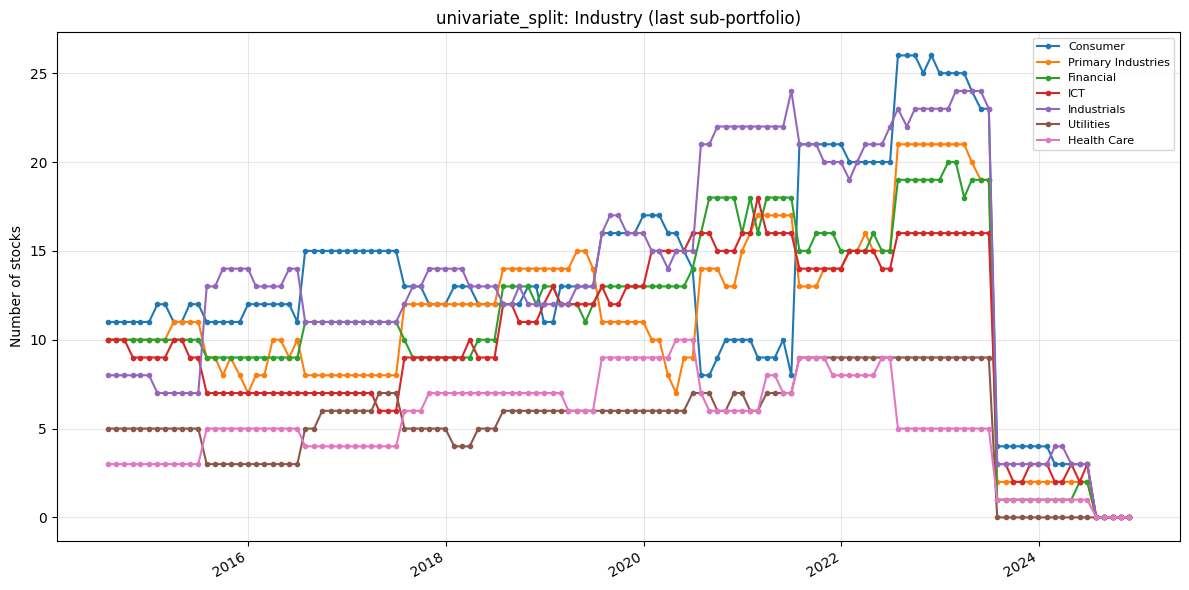

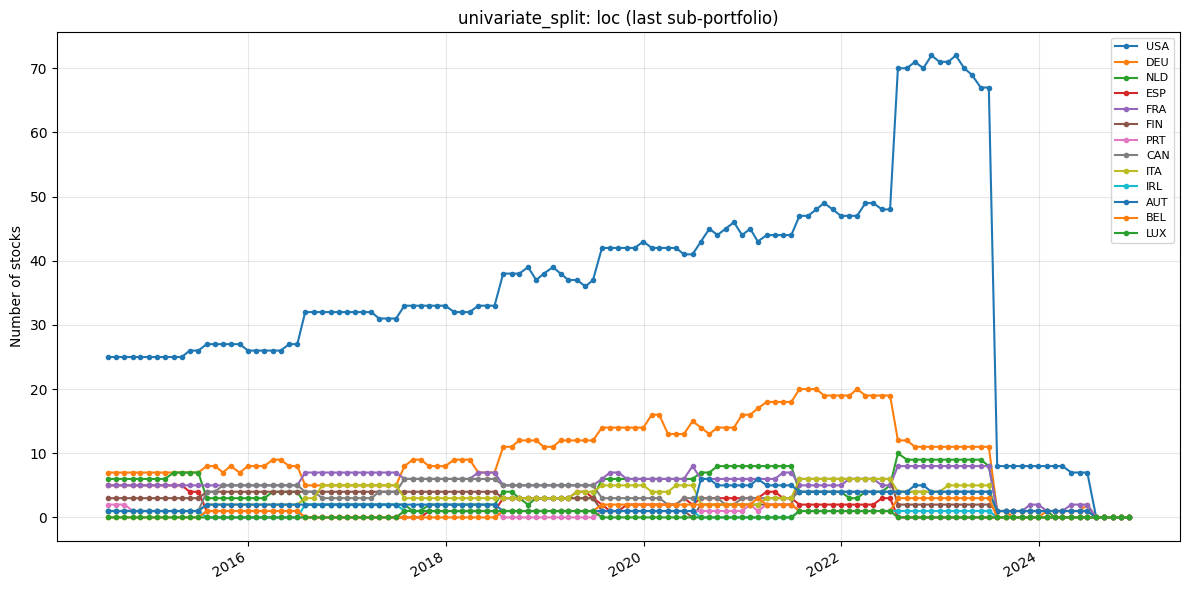

ValueError: No constituents to plot after filtering.

In [ ]:
from IPython.display import display
from functions.portfolio_metrics.Portfolio_Constituents import PortfolioConstituents

# Portfolio constituents inspection is pinned to signal_2.
signal_2_simple_quantiles_constituents = signal_quantile_constituents["signal_2"]

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
#pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
